In [1]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import os
from adjustText import adjust_text

In [2]:
data_dir = "results"
file_list = sorted([f for f in os.listdir(data_dir) if f.endswith(".npy")])
vectorized_data = []

for fname in file_list:
    matrix = np.load(os.path.join(data_dir, fname))
    vector = matrix.flatten()
    
    # Normalize the vector using L1 norm
    norm_vector = normalize(vector.reshape(1, -1), norm='l1')[0]
    vectorized_data.append(norm_vector)

X = np.vstack(vectorized_data)
print("Shape of X:", X.shape)

Shape of X: (129, 16320)


In [3]:
filenames = [os.path.splitext(f)[0] for f in file_list]

In [4]:
#K-mean
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

cluster_df = pd.DataFrame({
    'field': filenames,
    'cluster': labels
})

print(cluster_df.head())
print(cluster_df.sort_values(by='cluster'))

                                    field  cluster
0  Accounting Auditing and Accountability        6
1                   Aerospace Engineering        1
2              Agricultural Biotechnology        5
3    Agriculture Land and Farm Management        1
4                    Analytical Chemistry        0
                                        field  cluster
64                                 Immunology        0
27                         Cognitive Sciences        0
109                                Philosophy        0
108  Pharmacology and Pharmaceutical Sciences        0
106     Paediatrics and Reproductive Medicine        0
..                                        ...      ...
91                               Oceanography        7
111                             Plant Biology        7
21                    Business and Management        7
14                       Atmospheric Sciences        7
13            Astronomical and Space Sciences        7

[129 rows x 2 columns]


In [5]:
pca = PCA(n_components=2, random_state=2)
X_2d = pca.fit_transform(X) 

In [6]:
pca.explained_variance_ratio_

array([0.67051101, 0.22506813])

/var/folders/v9/_js75nzx64lf8__fmfsscg4c0000gn/T/ipykernel_45626/2464615903.py:21: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, ticks=range(n_clusters))


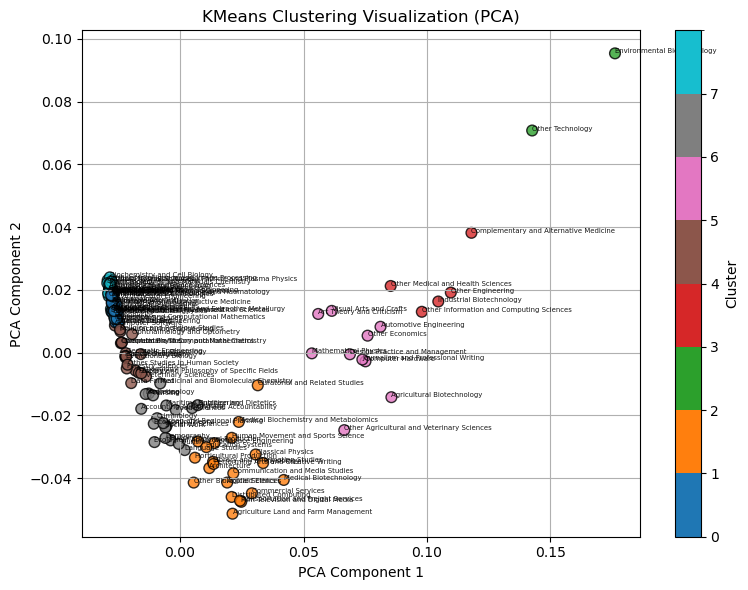

In [7]:
cmap = plt.get_cmap('tab10')
norm = BoundaryNorm(boundaries=range(n_clusters+1), ncolors=cmap.N)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels,
    cmap=cmap,
    norm=norm,
    s=60,
    alpha=0.8,
    edgecolor='k'
)
for i, (x, y) in enumerate(X_2d):
    plt.text(x, y, filenames[i], fontsize=5, alpha=0.9)

# colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # dummy array
cbar = plt.colorbar(sm, ticks=range(n_clusters))
cbar.set_label('Cluster')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clustering Visualization (PCA)')
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/v9/_js75nzx64lf8__fmfsscg4c0000gn/T/ipykernel_45626/2495712220.py:18: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm, ticks=range(n_clusters))


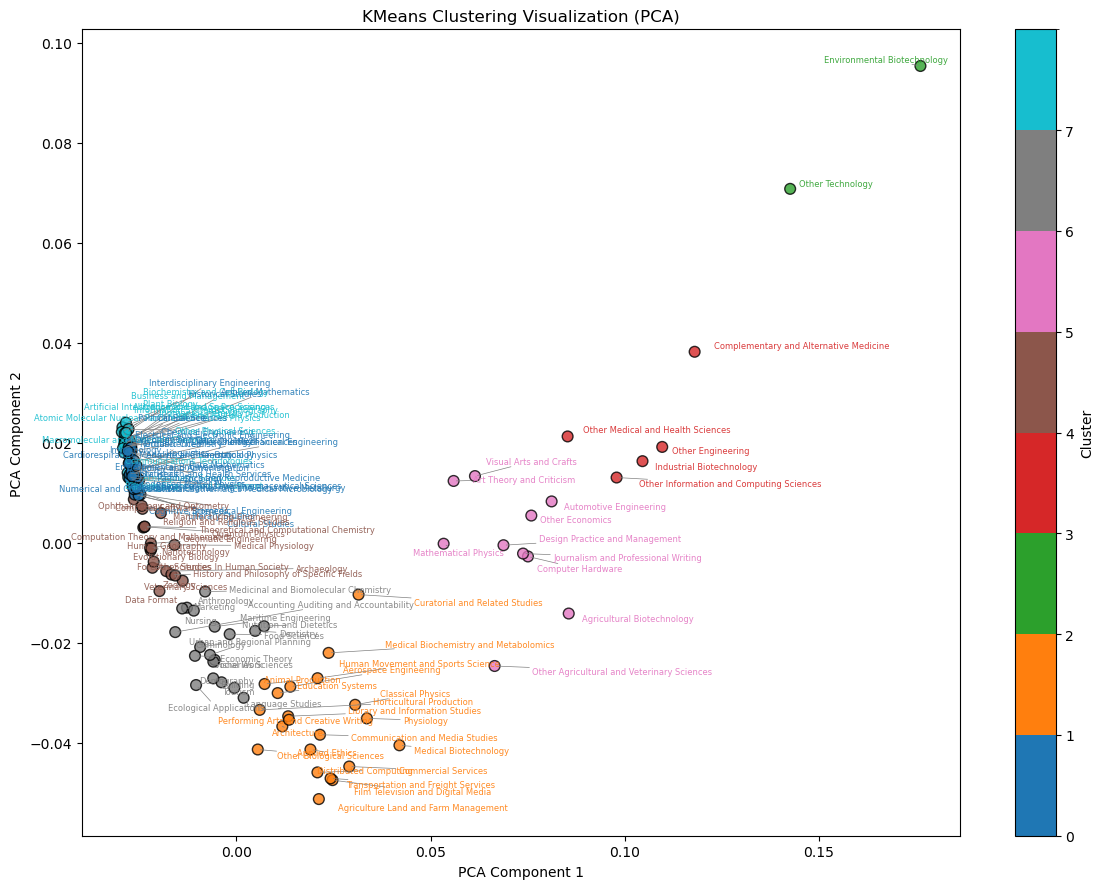

In [8]:
cmap = plt.get_cmap('tab10')
norm = BoundaryNorm(boundaries=range(n_clusters+1), ncolors=cmap.N)

plt.figure(figsize=(12, 9))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=labels,
    cmap=cmap,
    norm=norm,
    s=60,
    alpha=0.8,
    edgecolor='k'
)

# colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ticks=range(n_clusters))
cbar.set_label('Cluster')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clustering Visualization (PCA)')
plt.grid(False)

texts = []
for i, (x, y) in enumerate(X_2d):
    texts.append(plt.text(
        x, y, filenames[i],
        fontsize=6,
        color=cmap(norm(labels[i])),
        alpha=0.9
    ))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.tight_layout()
plt.savefig("cluster_colored_labels_l1.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [10]:
testgroup = 7
cluster_fields = cluster_df[cluster_df['cluster'] == testgroup]
cluster_fields

,field,cluster
13,Astronomical and Space Sciences,7
15,Atomic Molecular Nuclear Particle and Plasma P...,7
18,Biochemistry and Cell Biology,7
103,Other Physical Sciences,7
111,Plant Biology,7


In [11]:
betti_matrices_subfield = {}

for field in cluster_fields['field']:
    var_name = field.lower().replace(" ", "_").replace("&", "and")
    
    filepath = os.path.join(data_dir, f"{field}.npy")
    betti_matrices_subfield[var_name] = np.load(filepath)

In [12]:
betti_matrices_all = {}

for field in filenames:
    var_name = field.lower().replace(" ", "_").replace("&", "and")
    filepath = os.path.join(data_dir, f"{field}.npy")
    betti_matrices_all[var_name] = np.load(filepath)

In [13]:
years = np.linspace(0, 1, 102).tolist()
inv_counts = 1 / np.arange(40, 0, -1)

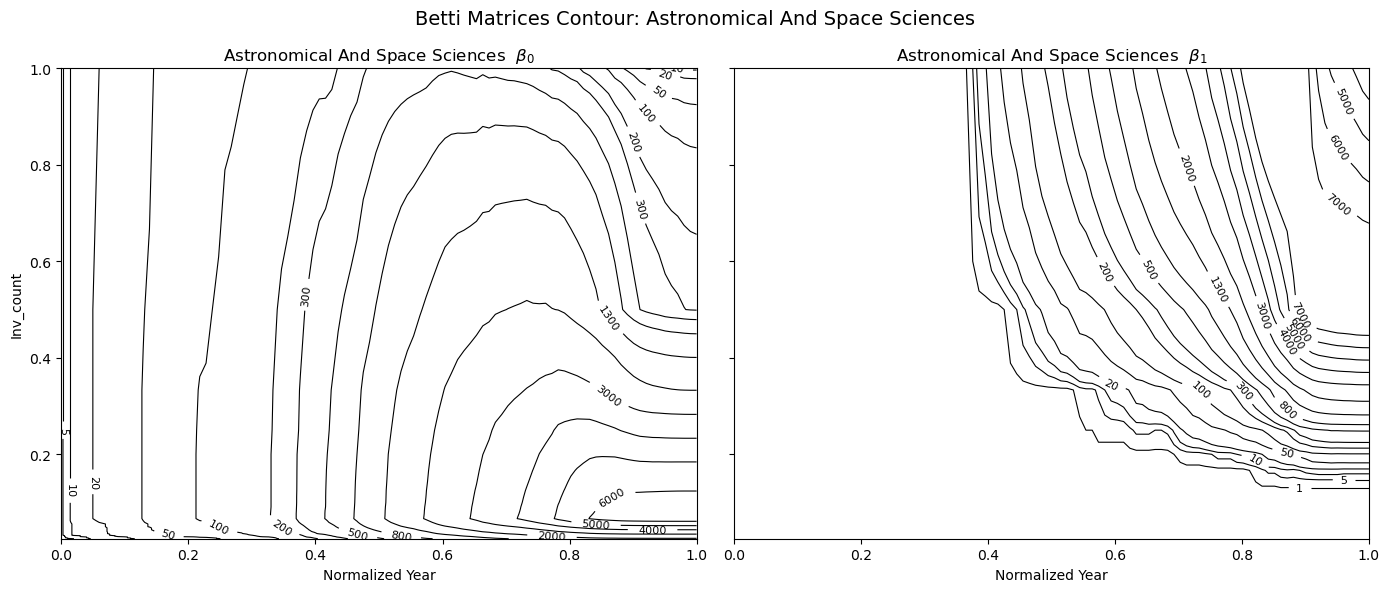

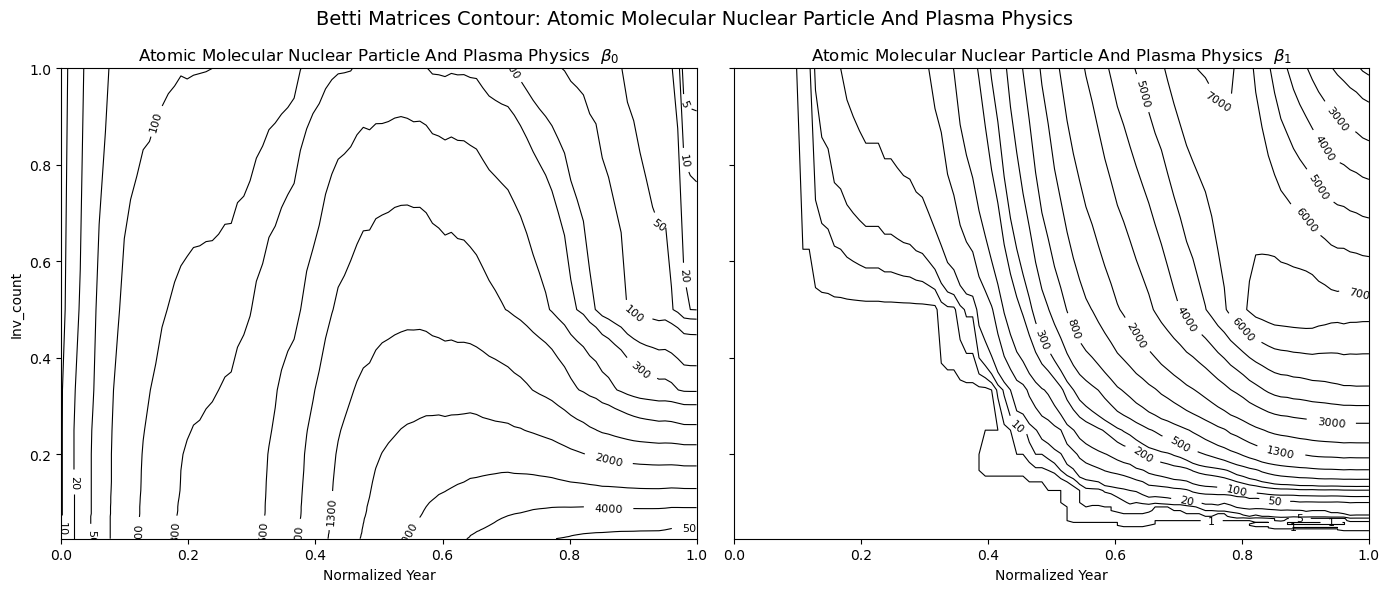

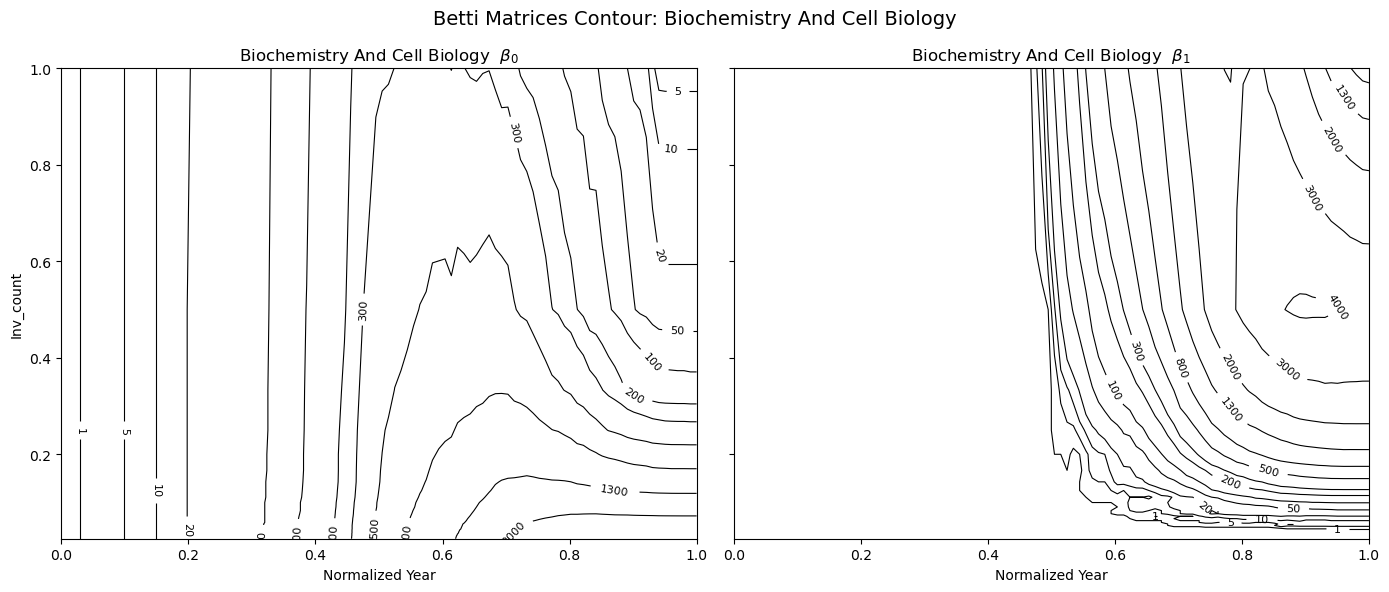

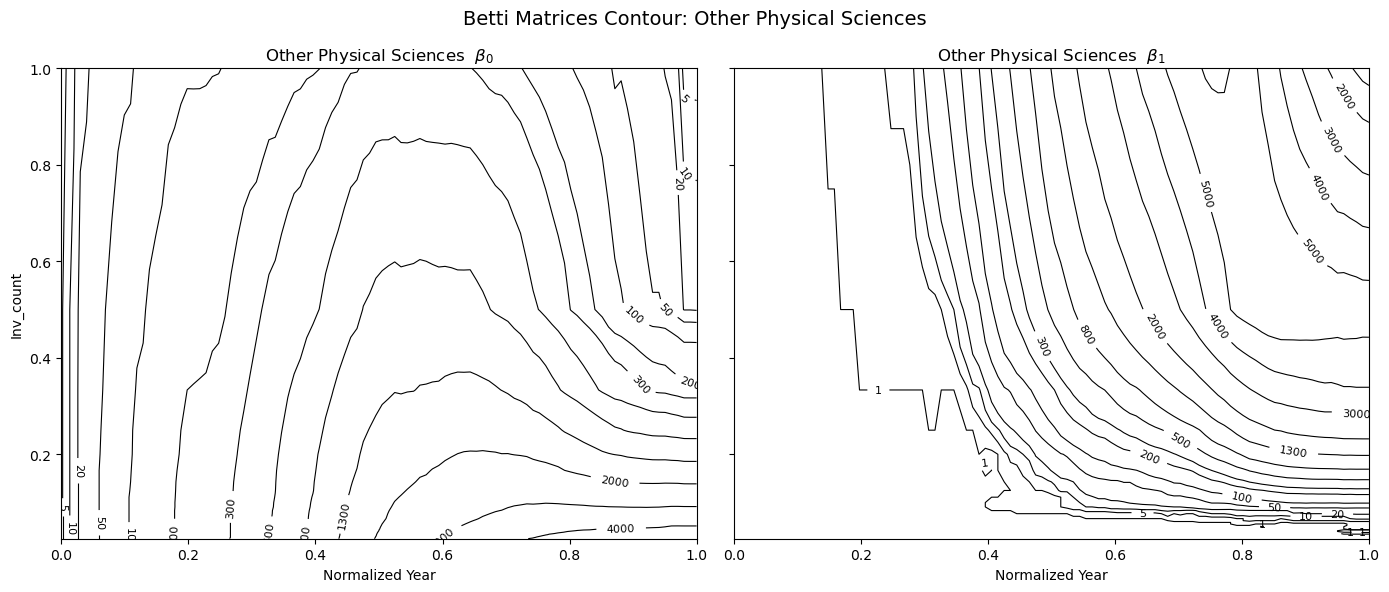

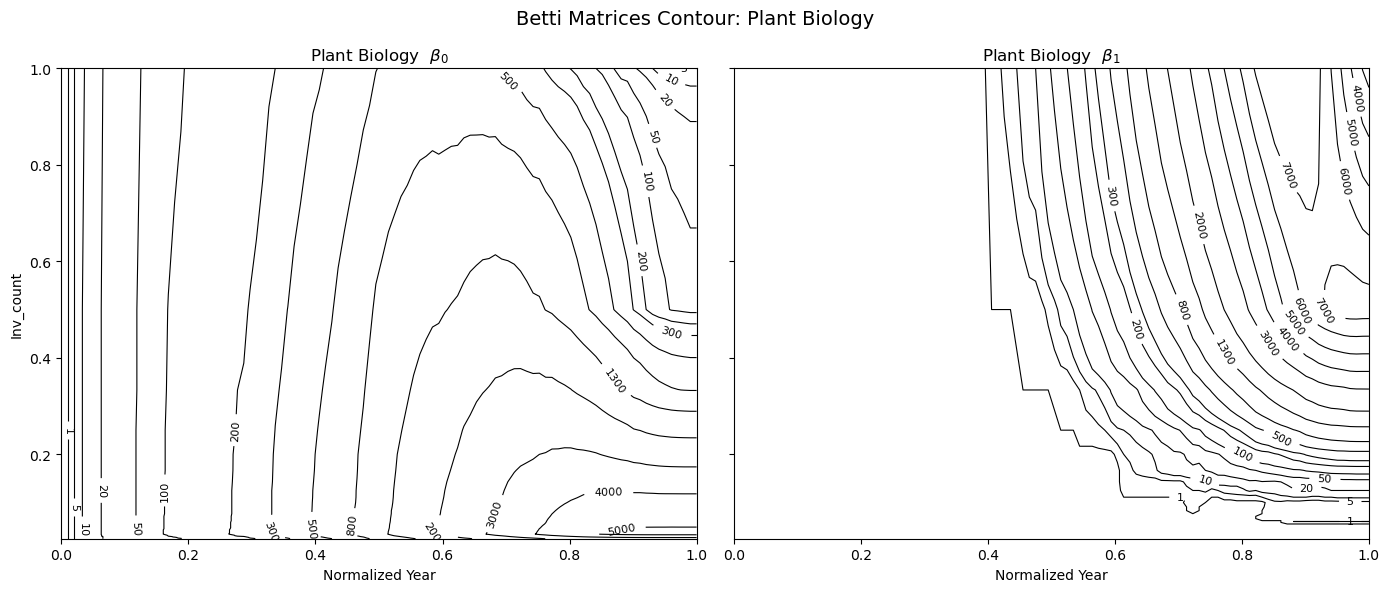

In [14]:
X1, Y = np.meshgrid(years, inv_counts)

levels = [1, 5, 10, 20, 50, 100, 200, 300, 500, 800, 1300, 2000, 3000, 4000,5000,6000,7000]

for name, matrix in betti_matrices_subfield.items():
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    for dim, ax in enumerate(axs):
        Z = matrix[:, :, dim].T
        cp = ax.contour(X1, Y, Z, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(cp, inline=True, fontsize=8)
        ax.set_xlabel("Normalized Year")
        ax.set_title(f"{name.replace('_', ' ').title()}  $\\beta_{dim}$")
    
    axs[0].set_ylabel("Inv_count")
    plt.suptitle(f"Betti Matrices Contour: {name.replace('_', ' ').title()}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [15]:
indices = cluster_fields.index.to_list()
X_sub = X[indices]
mean_vector = np.mean(X_sub, axis=0)
dists = euclidean_distances(X_sub, mean_vector.reshape(1, -1)).flatten()
representative_idx = indices[np.argmin(dists)]
representative_field = filenames[representative_idx]
print("mean field:", representative_field)

mean field: Atomic Molecular Nuclear Particle and Plasma Physics


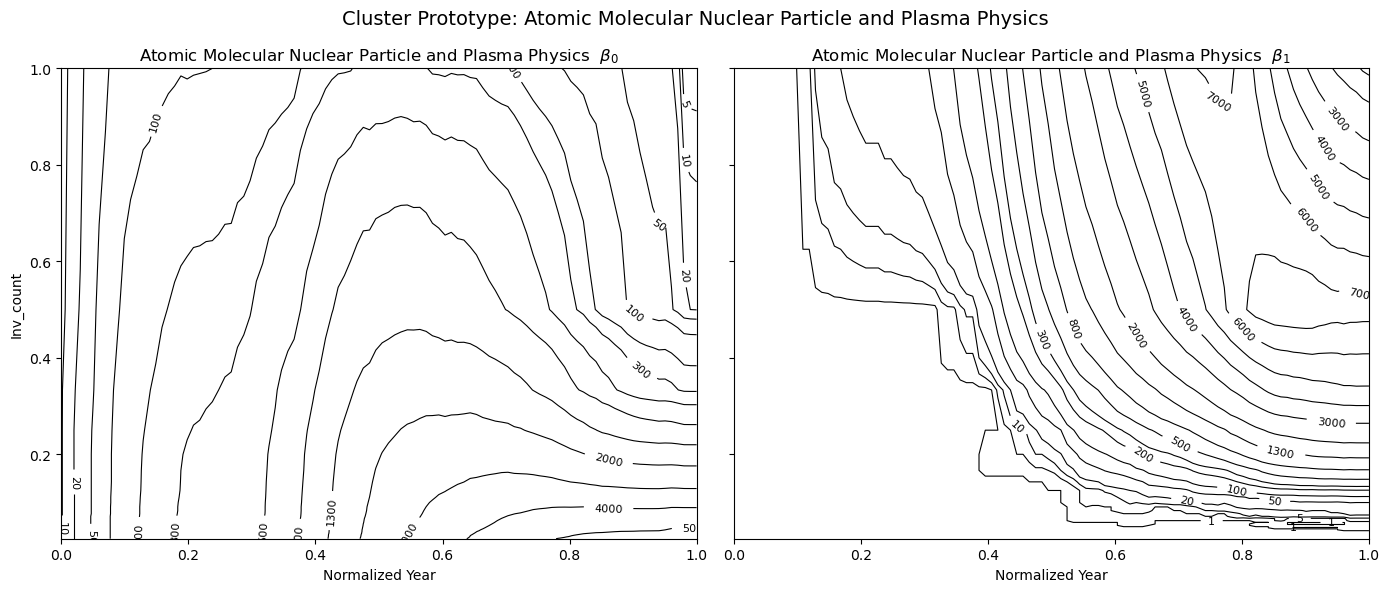

In [16]:
var_name = representative_field.lower().replace(" ", "_").replace("&", "and")

matrix = betti_matrices_subfield[var_name]

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for dim, ax in enumerate(axs):
    Z = matrix[:, :, dim].T
    cp = ax.contour(X1, Y, Z, levels=levels, colors='black', linewidths=0.8)
    ax.clabel(cp, inline=True, fontsize=8)
    ax.set_xlabel("Normalized Year")
    ax.set_title(f"{representative_field}  $\\beta_{dim}$")
axs[0].set_ylabel("Inv_count")
plt.suptitle(f"Cluster Prototype: {representative_field}", fontsize=14)
plt.tight_layout()
plt.show()

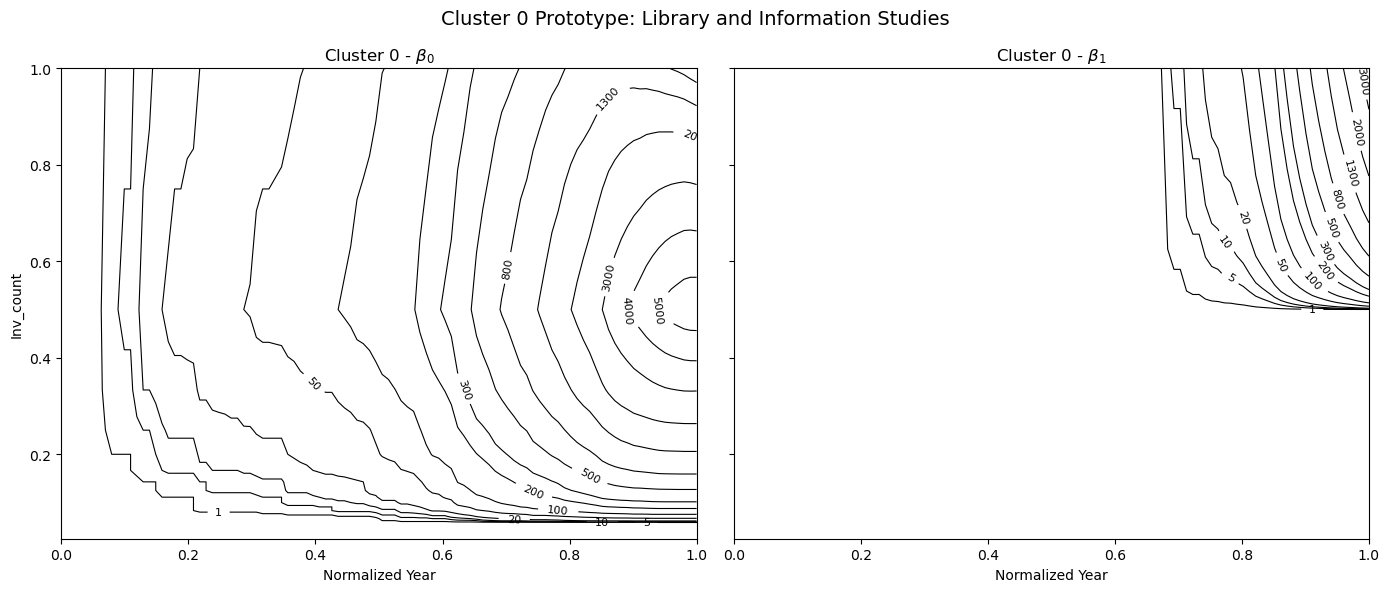

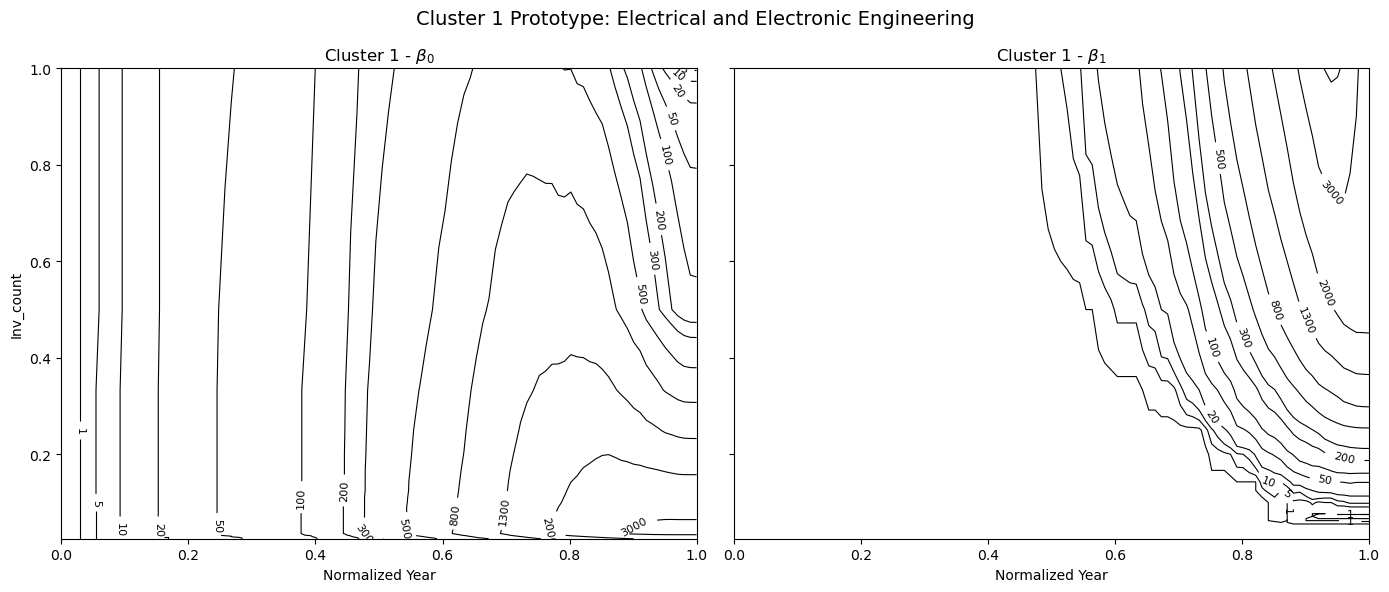

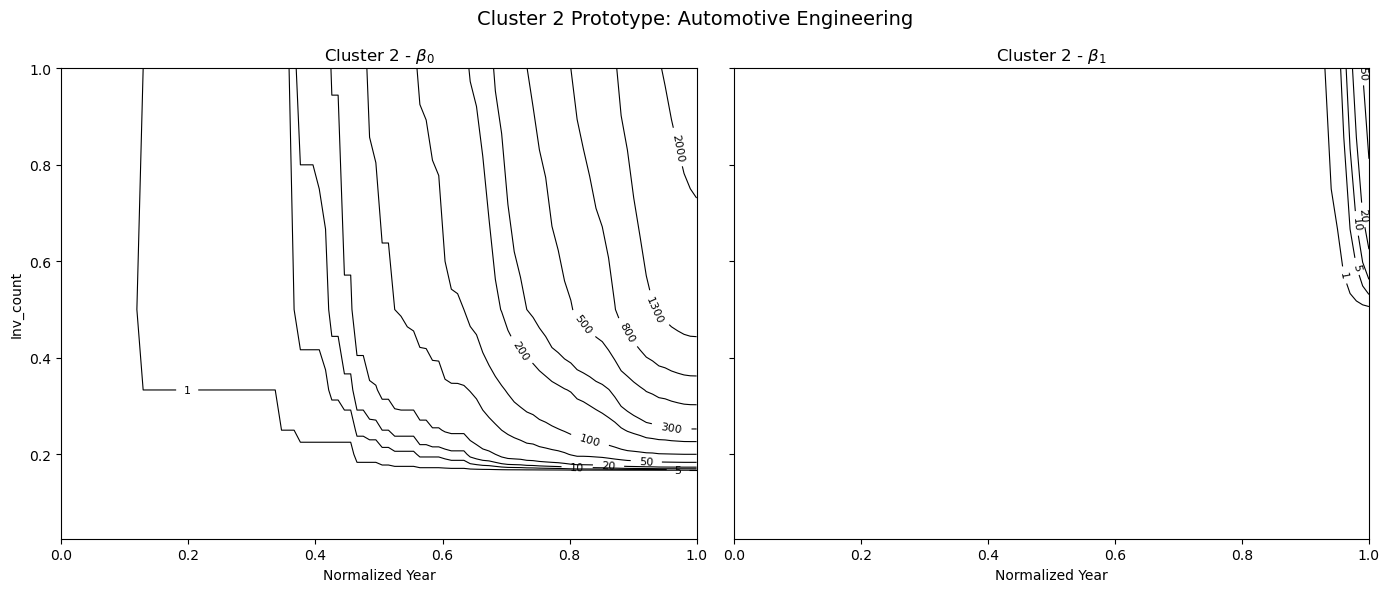

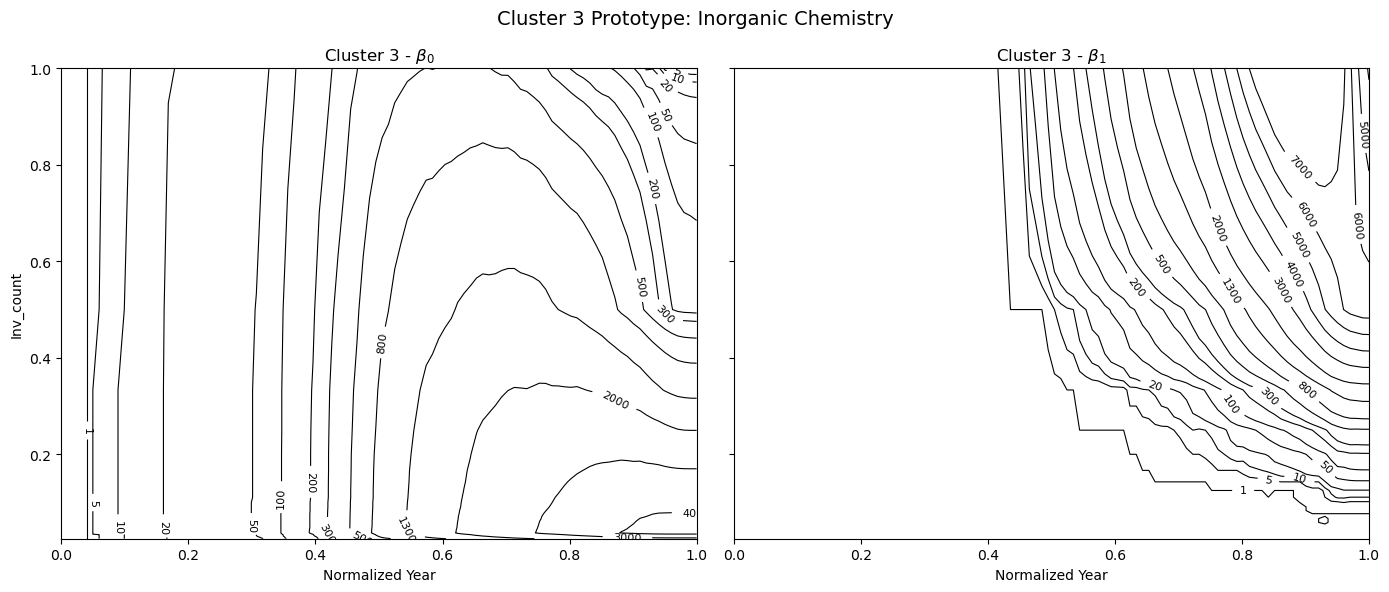

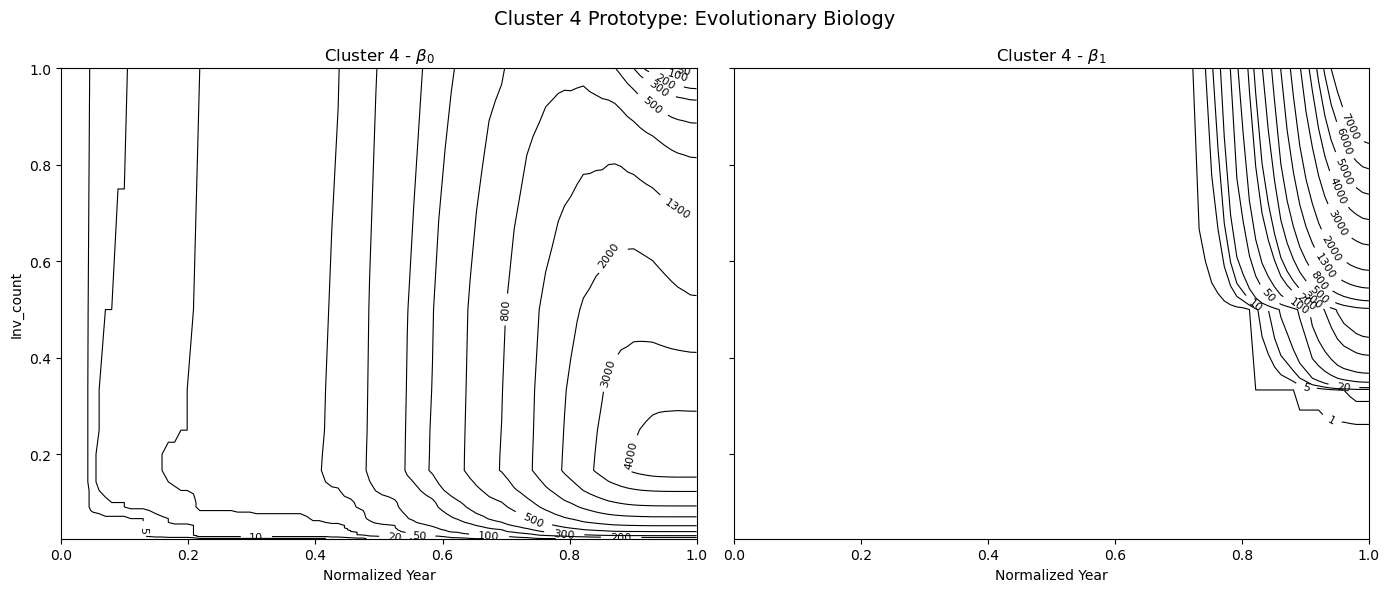

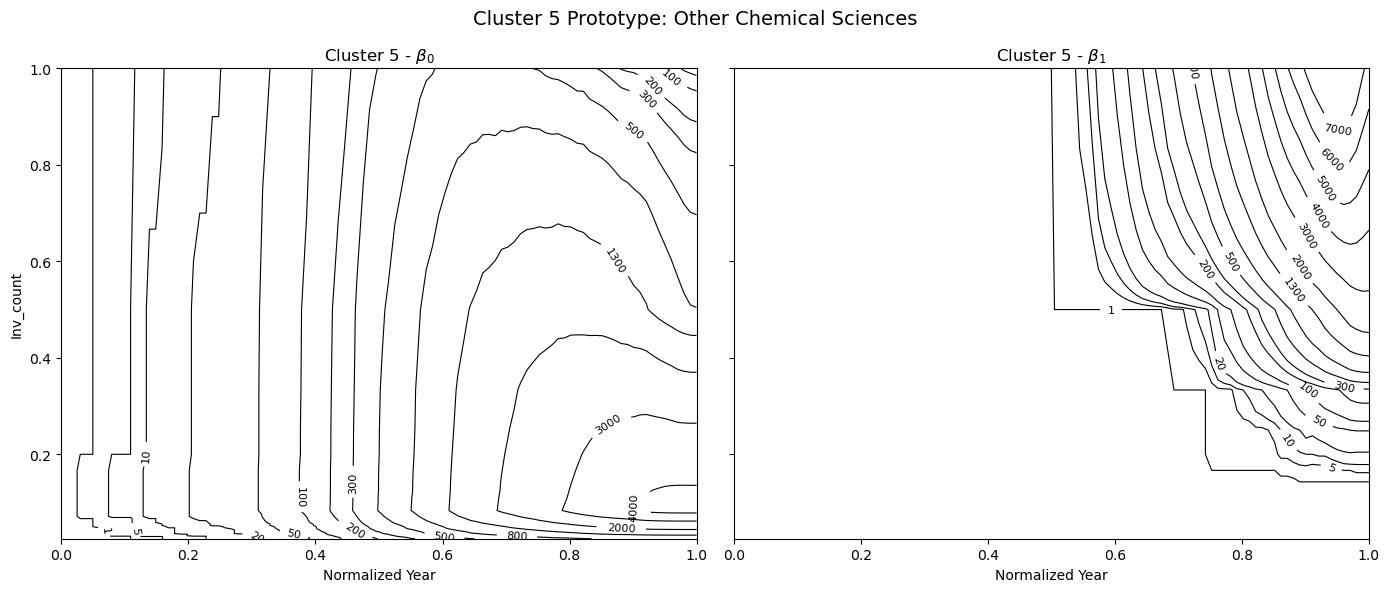

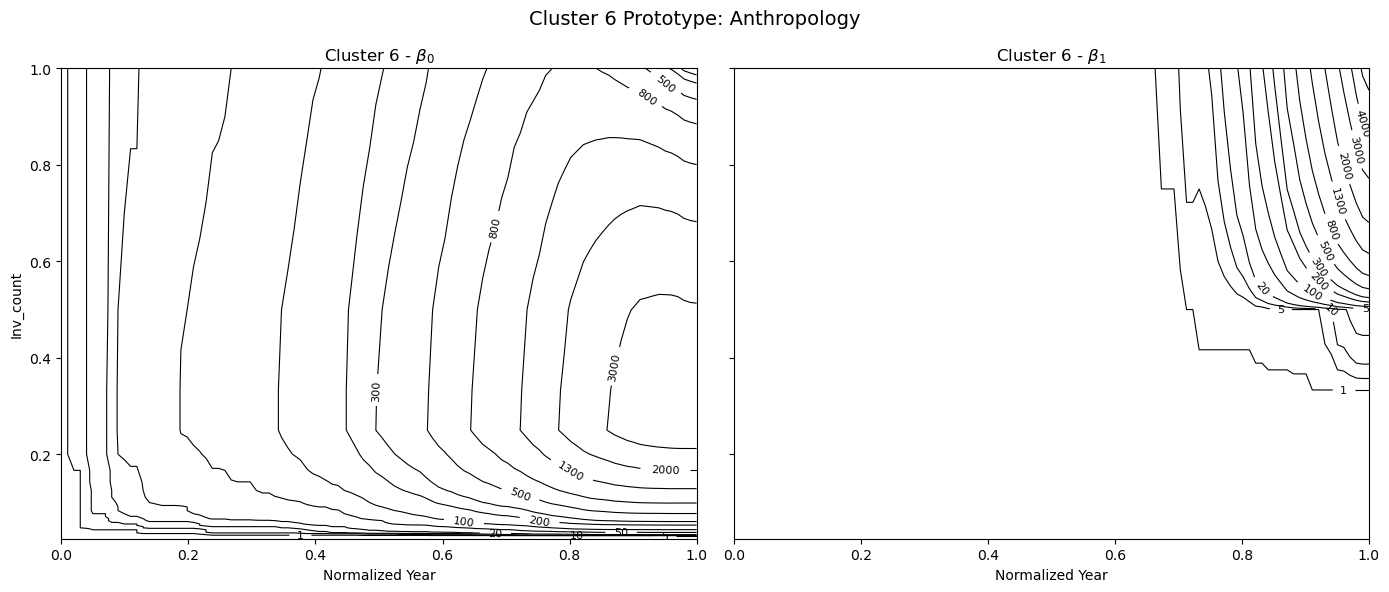

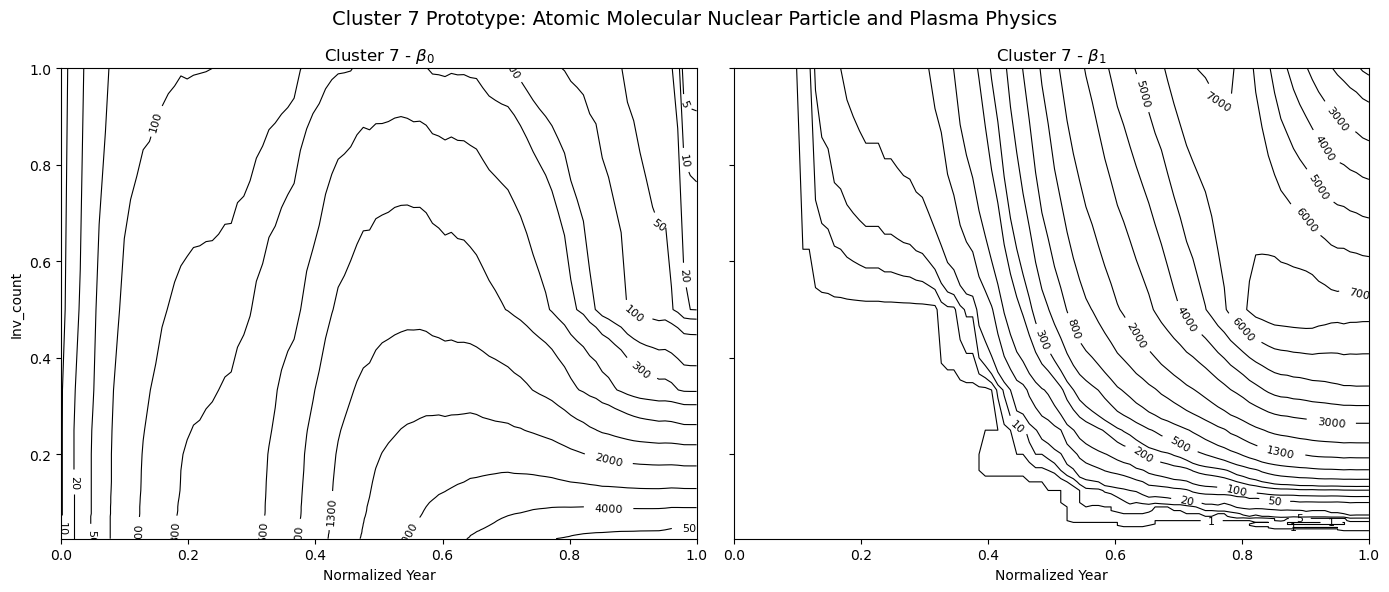

In [17]:
cluster_prototypes = {}

for group in range(n_clusters):
    cluster_fields = cluster_df[cluster_df['cluster'] == group]
    indices = cluster_fields.index.to_list()
    
    X_sub = X[indices]
    mean_vector = np.mean(X_sub, axis=0)
    
    dists = euclidean_distances(X_sub, mean_vector.reshape(1, -1)).flatten()
    representative_idx = indices[np.argmin(dists)]
    representative_field = filenames[representative_idx]
    cluster_prototypes[group] = representative_field

    var_name = representative_field.lower().replace(" ", "_").replace("&", "and")
    
    matrix = betti_matrices_all[var_name]
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    for dim, ax in enumerate(axs):
        Z = matrix[:, :, dim].T
        cp = ax.contour(X1, Y, Z, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(cp, inline=True, fontsize=8)
        ax.set_xlabel("Normalized Year")
        ax.set_title(f"Cluster {group} - $\\beta_{dim}$")
    axs[0].set_ylabel("Inv_count")
    plt.suptitle(f"Cluster {group} Prototype: {representative_field}", fontsize=14)
    plt.tight_layout()
    plt.show()

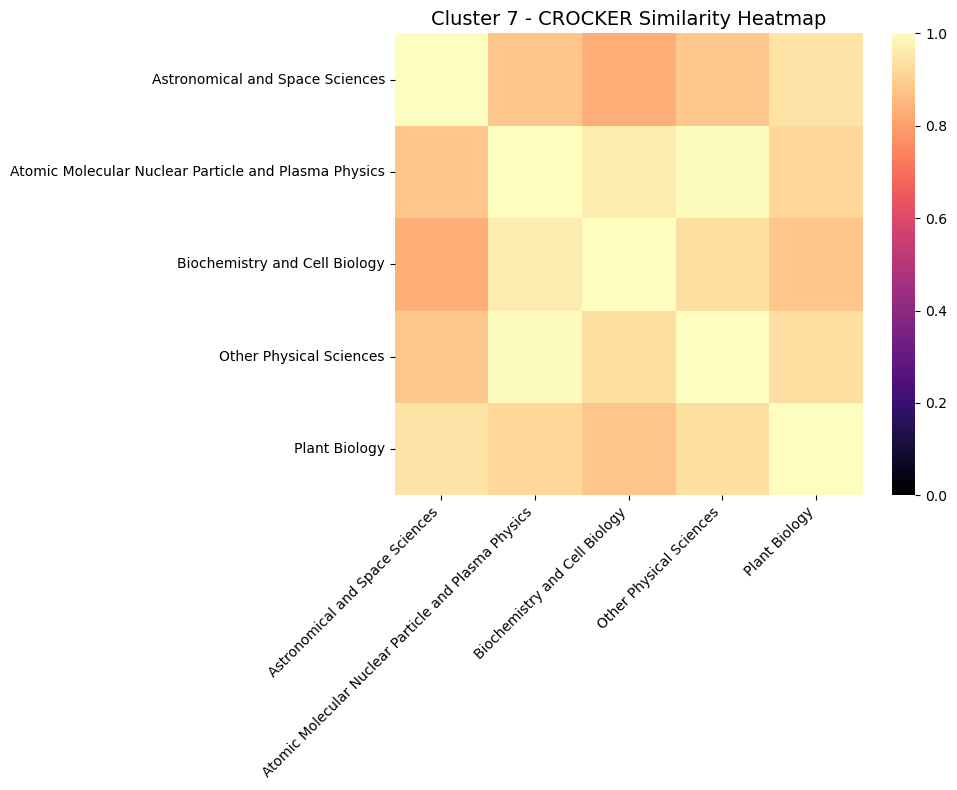

In [18]:
vectors = []
valid_names = []

for field in cluster_fields['field']:
    var_name = field.lower().replace(" ", "_").replace("&", "and")
    matrix = betti_matrices_subfield[var_name]
    vec = matrix.flatten()
    vectors.append(vec)
    valid_names.append(field)

X_cluster = np.vstack(vectors)
sim_matrix = cosine_similarity(X_cluster)

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, xticklabels=valid_names, yticklabels=valid_names, cmap='magma', vmin=0, vmax=1)
plt.xticks(rotation=45, ha='right')
plt.title(f"Cluster {testgroup} - CROCKER Similarity Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

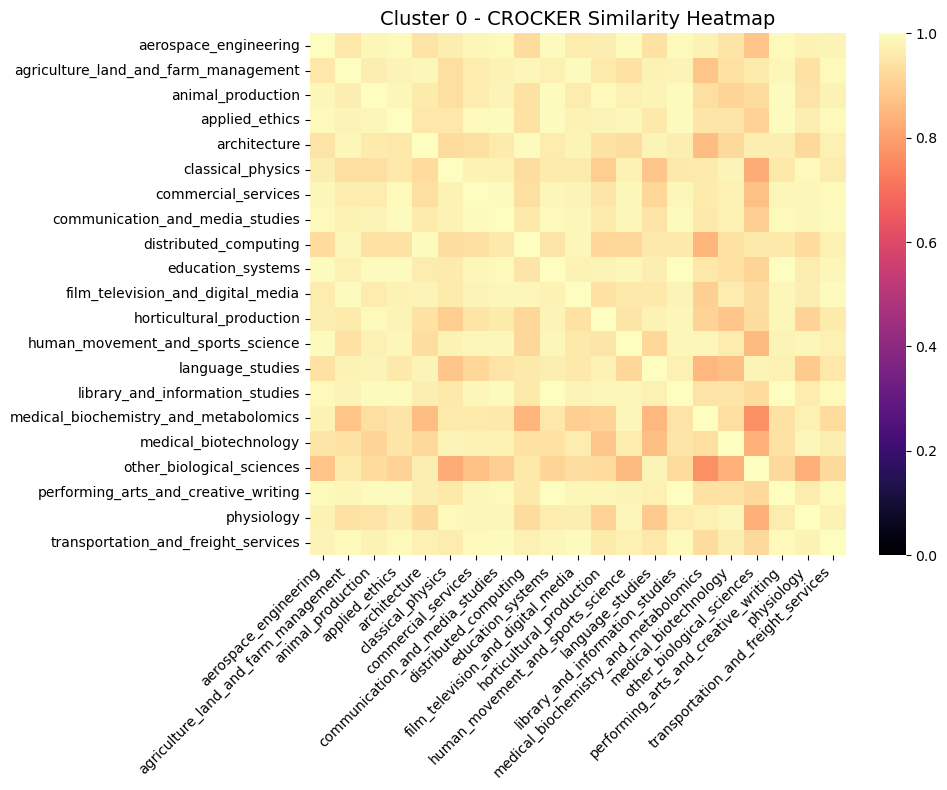

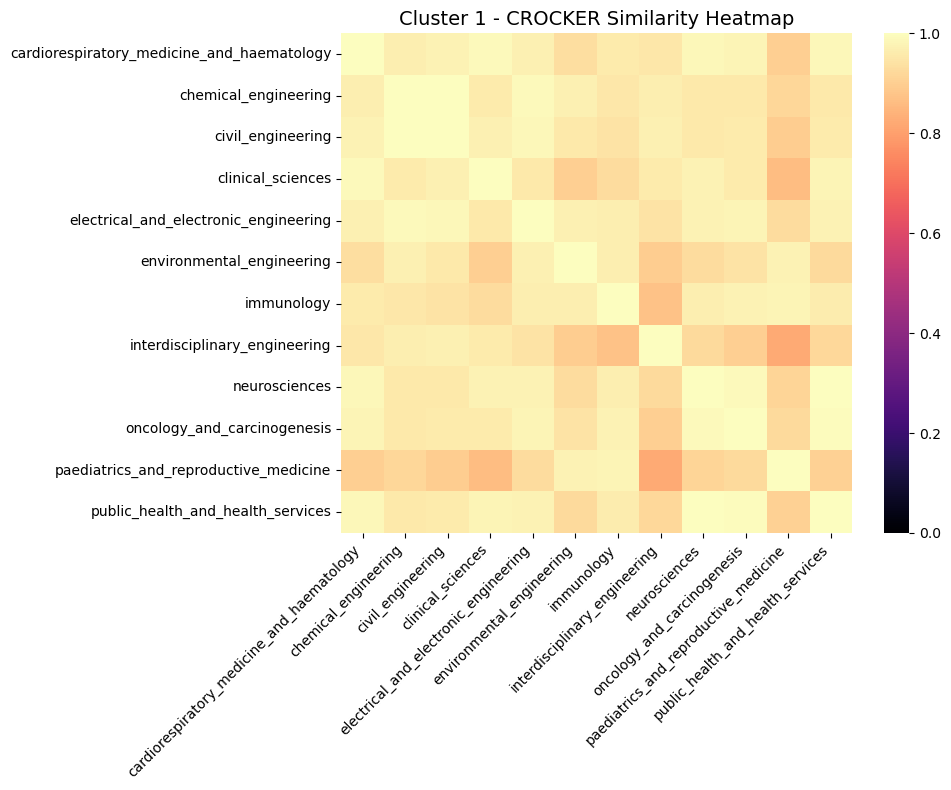

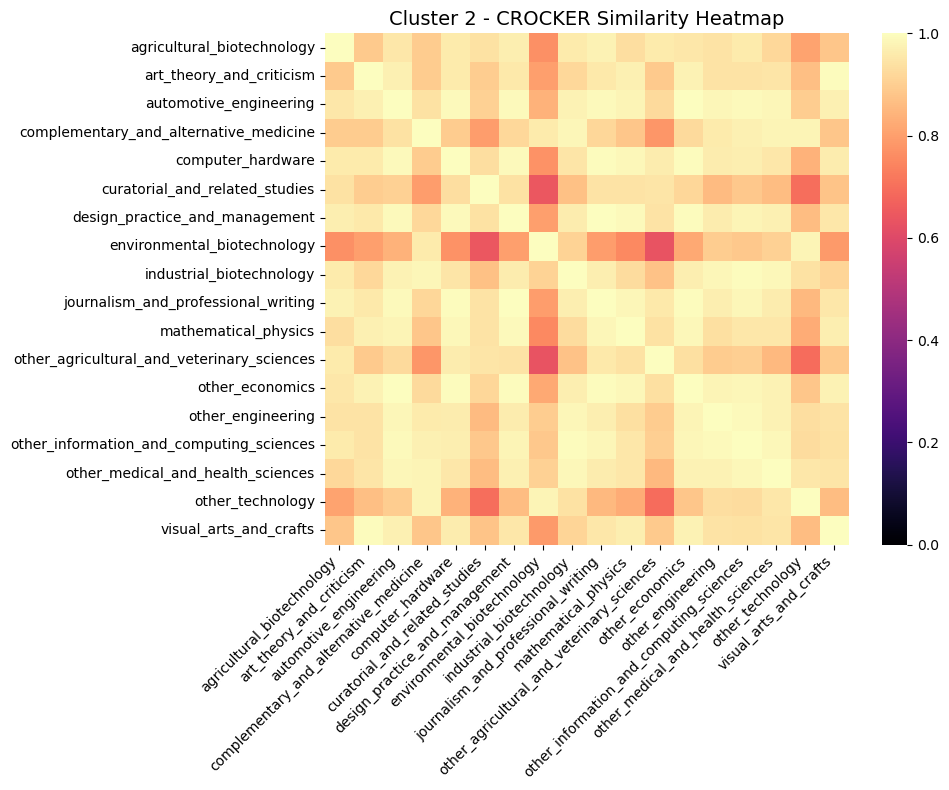

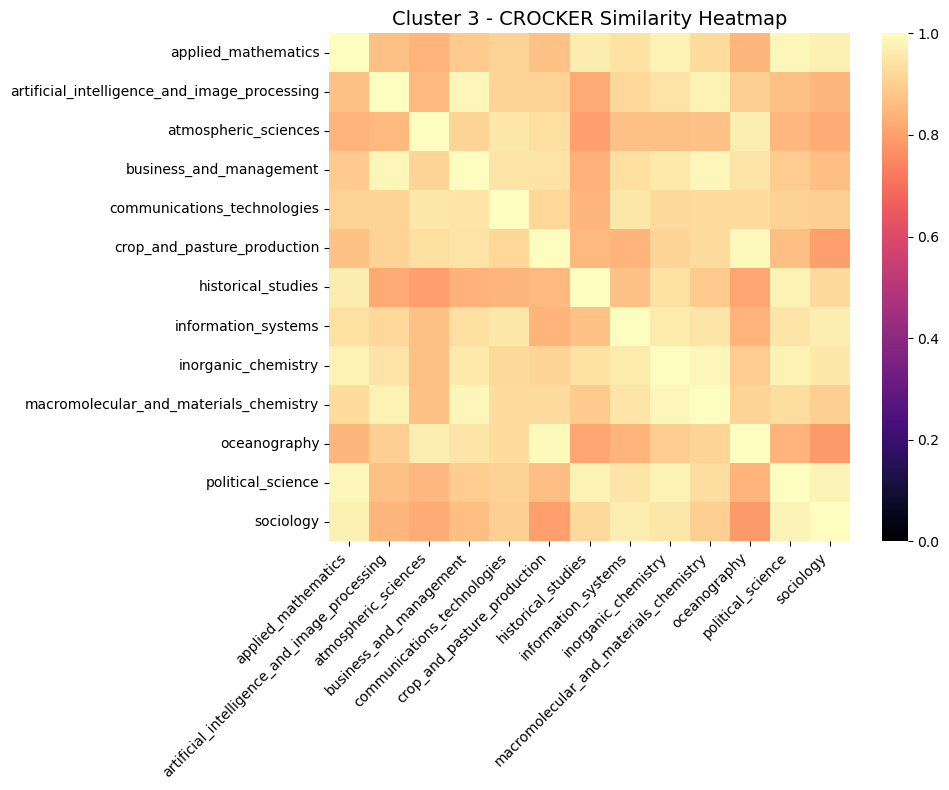

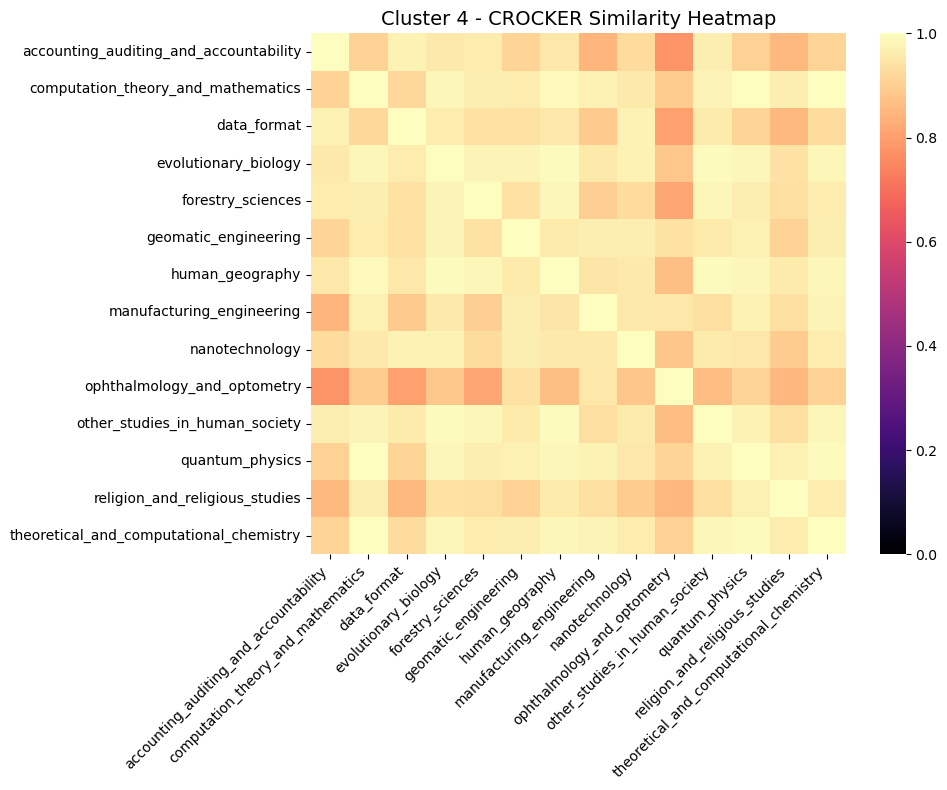

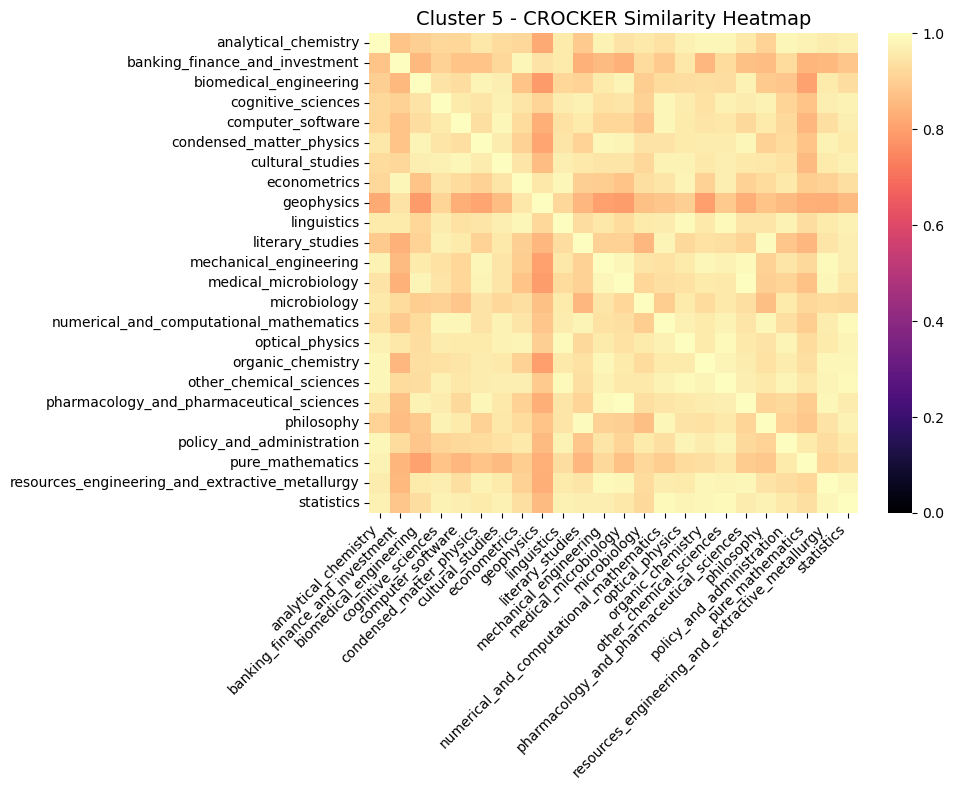

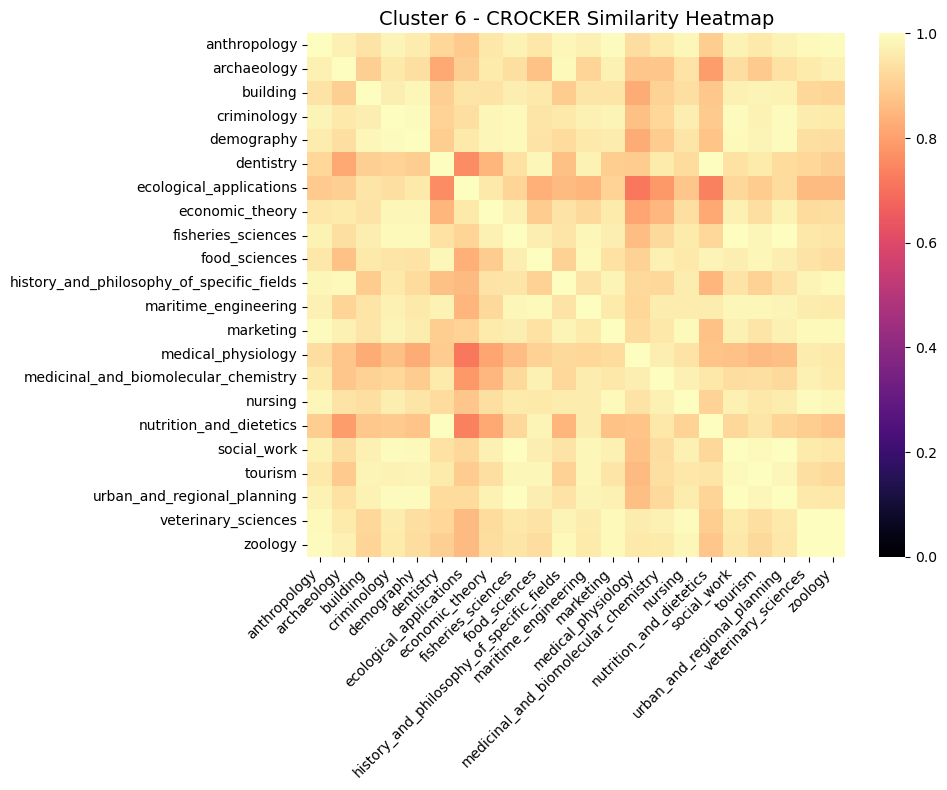

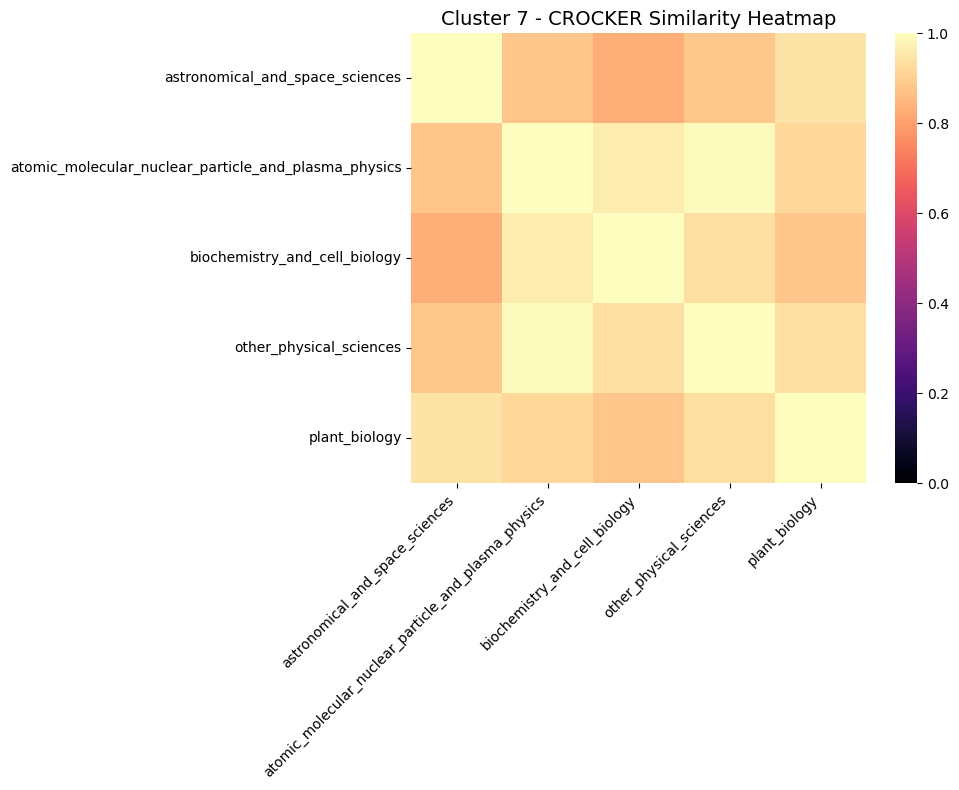

In [19]:
for testgroup in range(n_clusters):
    cluster_fields = cluster_df[cluster_df['cluster'] == testgroup]
    betti_matrices_subfield = {}
    
    for field in cluster_fields['field']:
        var_name = field.lower().replace(" ", "_").replace("&", "and")
        filepath = os.path.join(data_dir, f"{field}.npy")
        betti_matrices_subfield[var_name] = np.load(filepath)
    vectors = []
    valid_names = []
    
    for var_name, matrix in betti_matrices_subfield.items():
        vec = matrix.flatten()
        vectors.append(vec)
        valid_names.append(var_name)
    
    X_cluster = np.vstack(vectors)
    sim_matrix = cosine_similarity(X_cluster)

    plt.figure(figsize=(10, 8))
    sns.heatmap(sim_matrix, xticklabels=valid_names, yticklabels=valid_names,
                cmap='magma', vmin=0, vmax=1)
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Cluster {testgroup} - CROCKER Similarity Heatmap", fontsize=14)
    plt.tight_layout()
    plt.show()


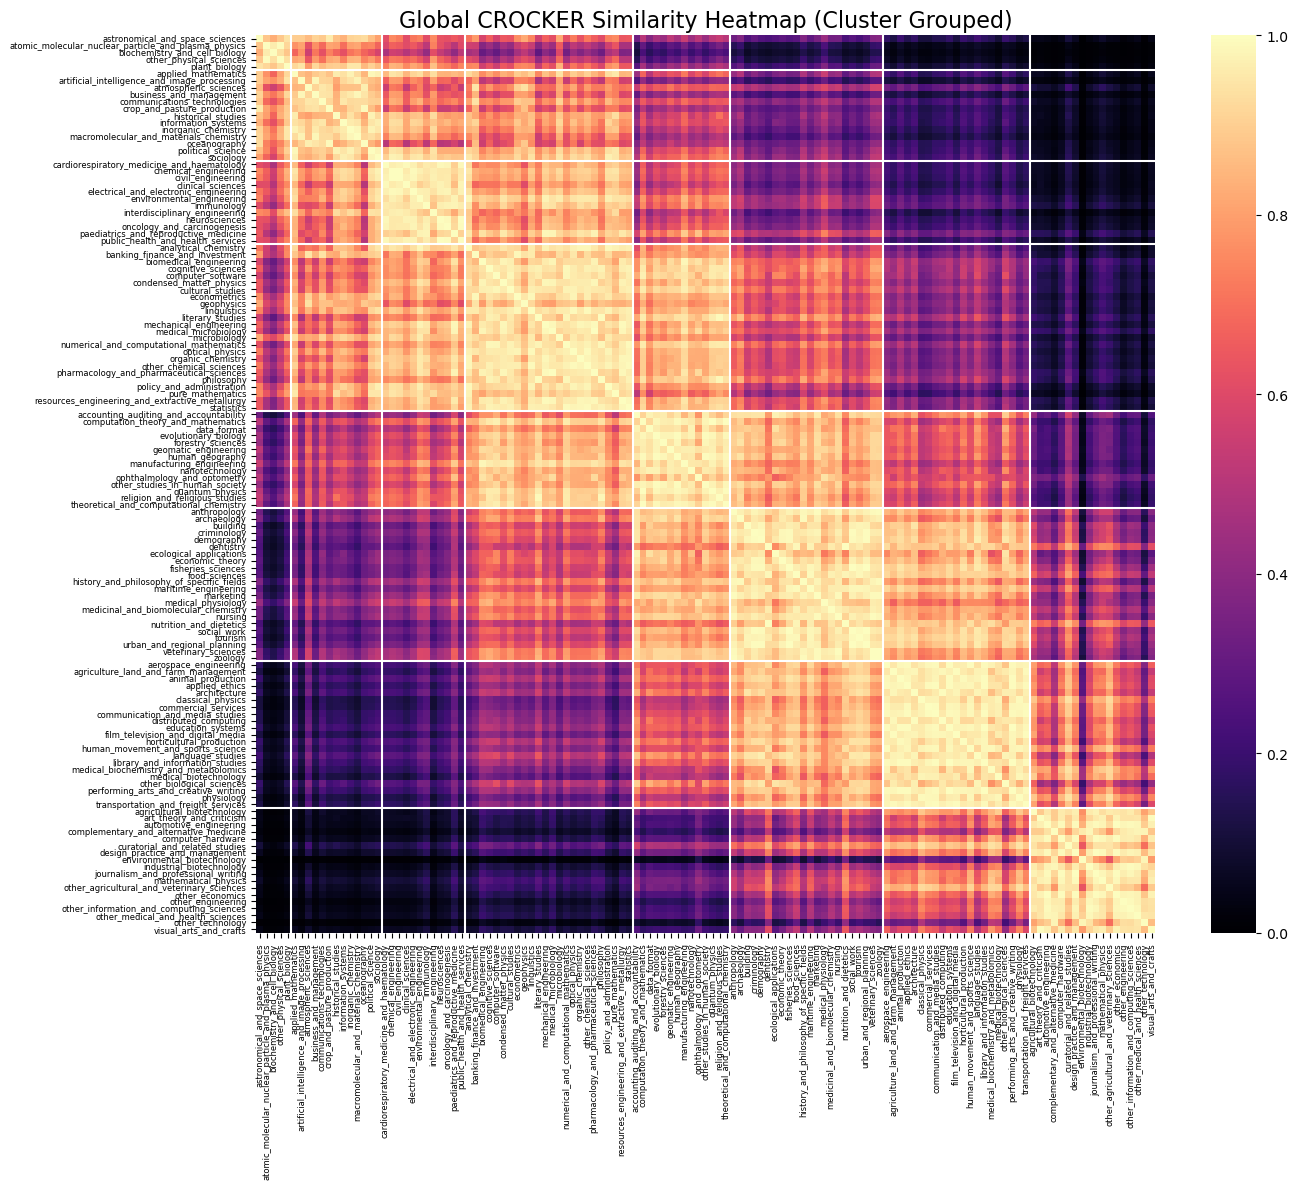

In [20]:
cluster_order = [7, 3, 1, 5, 4, 6, 0, 2]

sorted_fields = []
cluster_assignments = []

for cluster_id in cluster_order:
    fields = cluster_df[cluster_df['cluster'] == cluster_id]['field'].tolist()
    sorted_fields.extend(fields)
    cluster_assignments.extend([cluster_id] * len(fields))

vectors = []
valid_names = []

for field in sorted_fields:
    var_name = field.lower().replace(" ", "_").replace("&", "and")
    filepath = os.path.join(data_dir, f"{field}.npy")
    matrix = np.load(filepath)
    vectors.append(matrix.flatten())
    valid_names.append(var_name)

X_all = np.vstack(vectors)
sim_matrix = cosine_similarity(X_all)

plt.figure(figsize=(14, 12))
sns.heatmap(sim_matrix, xticklabels=valid_names, yticklabels=valid_names,
            cmap='magma', vmin=0, vmax=1)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.title("Global CROCKER Similarity Heatmap (Cluster Grouped)", fontsize=16)
plt.tight_layout()

cluster_lengths = [cluster_assignments.count(i) for i in cluster_order]
tick_locs = np.cumsum(cluster_lengths)[:-1]

for loc in tick_locs:
    plt.axhline(loc, color='white', lw=1.5)
    plt.axvline(loc, color='white', lw=1.5)
plt.savefig("heat_map_angle_sort_cluster.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [21]:
dfx2d = pd.DataFrame({
    'field': filenames,
    'x': X_2d[:, 0],
    'y': X_2d[:, 1]
})

dfx2d['angle'] = np.arctan2(dfx2d['y']-0.1, dfx2d['x']-0.2)

dfx2d['angle_shifted'] = (np.pi / 2 - dfx2d['angle']) % (2 * np.pi)

dfx2d_sorted = dfx2d.sort_values(by='angle_shifted').reset_index(drop=True)
sorted_fields_x2d = dfx2d_sorted['field'].tolist()

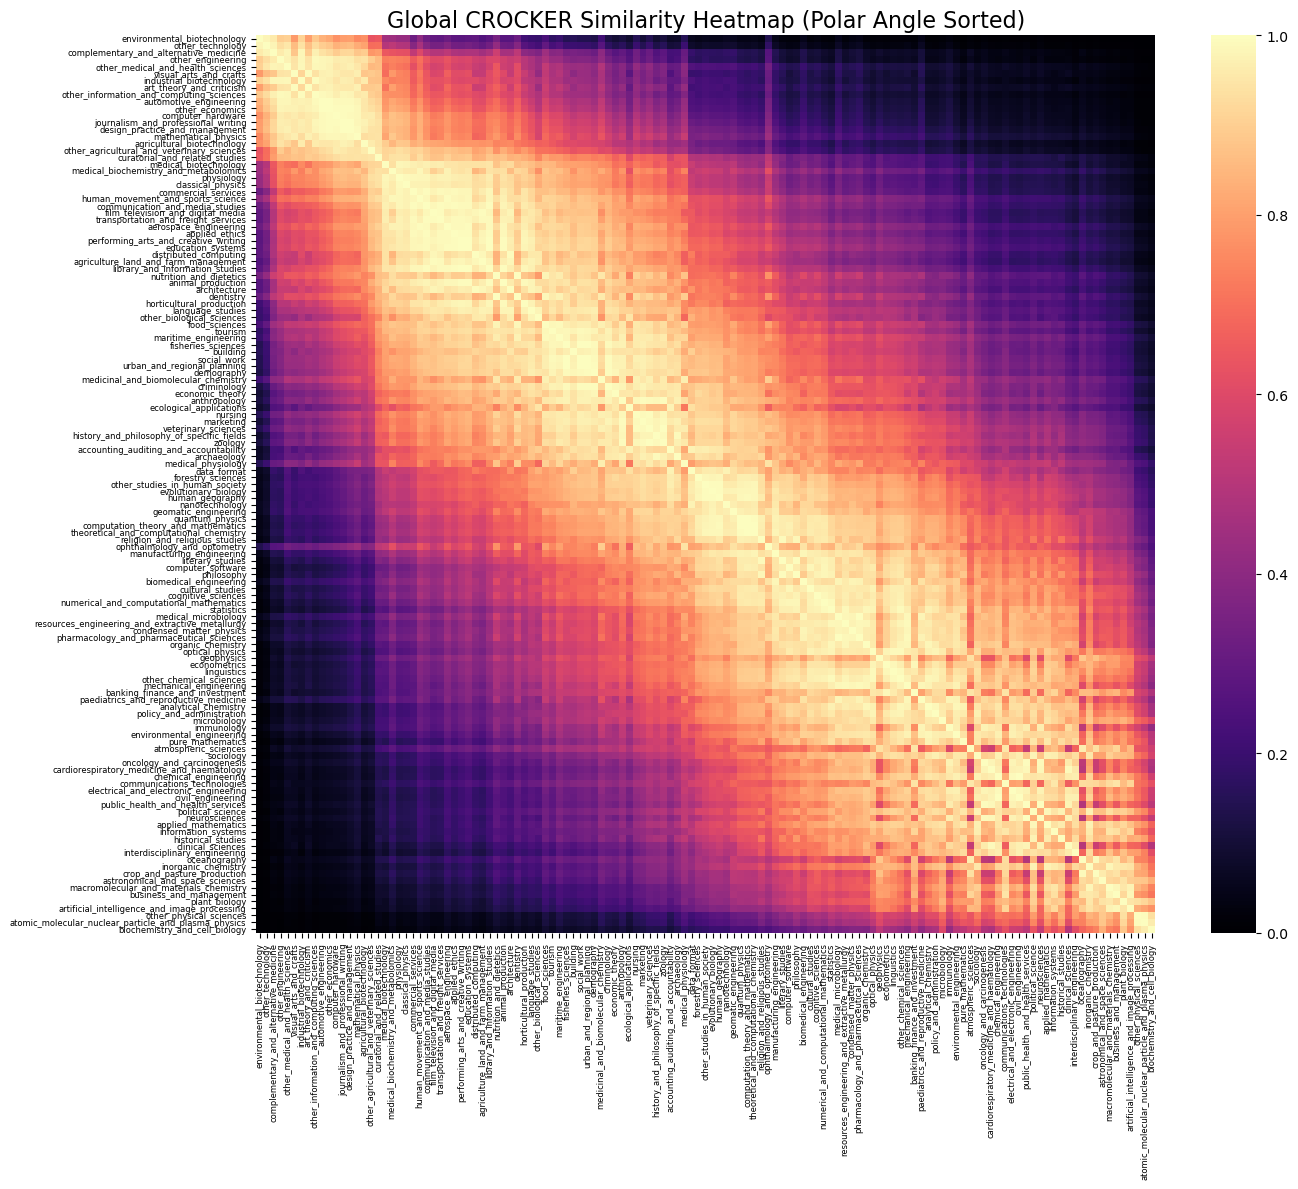

In [22]:
vectors_x2d = []
valid_names_x2d = []

for field in sorted_fields_x2d:
    var_name = field.lower().replace(" ", "_").replace("&", "and")
    filepath = os.path.join(data_dir, f"{field}.npy")
    matrix = np.load(filepath)
    vectors_x2d.append(matrix.flatten())
    valid_names_x2d.append(var_name)

X_all = np.vstack(vectors_x2d)
sim_matrix = cosine_similarity(X_all)

plt.figure(figsize=(14, 12))
sns.heatmap(sim_matrix, xticklabels=valid_names_x2d, yticklabels=valid_names_x2d,
            cmap='magma', vmin=0, vmax=1)

plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.title("Global CROCKER Similarity Heatmap (Polar Angle Sorted)", fontsize=16)
plt.tight_layout()
plt.savefig("heat_map_angle_sort_0102.pdf", format='pdf', bbox_inches='tight')
plt.show()


In [23]:
#medical biotech (green & blue)
#archaeology (grey & brown)
#inorganic chemistry (red & orange)
# * environmental engineering (orange & pink)